# rembg 배경 제거 검증 노트북
DB에서 제품 하나를 골라 배경 제거 결과를 시각적으로 확인합니다.

모델 성능 테스트 용

지금은 colab에서 진행 중

## 1. 라이브러리 로드

In [19]:
import os, sys
os.environ.pop("CURL_CA_BUNDLE", None)

PROJECT_ROOT = os.path.dirname(os.path.abspath("rembg_test.ipynb"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import certifi
import requests
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from rembg import new_session as rembg_new_session, remove as rembg_remove

print("BiRefNet 세션 로드 중...")
rembg_session = rembg_new_session("birefnet-general")
print("완료")


BiRefNet 세션 로드 중...
완료


## 2. DB 제품 목록 확인
아래 셀을 실행하면 벡터화 완료된 제품 목록이 출력됩니다.  
다음 셀의 `PICK_ID` 에 원하는 `id` 값을 입력하세요.

In [20]:
from db_manager import DBManager

db = DBManager()

# 카테고리별 전체 / 벡터화 완료 / 미완료 현황
with db.conn.cursor() as cur:
    cur.execute("""
        SELECT
            category,
            COUNT(*)                                      AS 전체,
            COUNT(*) FILTER (WHERE embedding IS NOT NULL) AS 벡터화완료,
            COUNT(*) FILTER (WHERE embedding IS NULL)     AS 미완료
        FROM products
        GROUP BY category
        ORDER BY category;
    """)
    stats = cur.fetchall()

print(f"{'카테고리':<14}  {'전체':>6}  {'벡터화완료':>10}  {'미완료':>6}")
print("-" * 45)
for cat, total, done, todo in stats:
    print(f"{cat:<14}  {total:>6}  {done:>10}  {todo:>6}")

# 벡터화 여부를 함께 표시하기 위해 embedding 컬럼 확인 (전체 조회, LIMIT 없음)
with db.conn.cursor() as cur:
    cur.execute("""
        SELECT id, category, title, image,
               CASE WHEN embedding IS NOT NULL THEN 'O' ELSE '-' END AS vec
        FROM products
        WHERE image IS NOT NULL AND image != ''
        ORDER BY id;
    """)
    product_list = cur.fetchall()

print(f"\n\n{'id':>5}  {'카테고리':<12}  {'벡터화':>4}  제품명")
print("-" * 75)
for pid, cat, title, _, vec in product_list:
    print(f"{pid:>5}  {cat:<12}  {vec:>4}  {title[:45]}")


카테고리                전체       벡터화완료     미완료
---------------------------------------------
DESK_SHELF         293         214      79
DESKTERIOR         121           0     121
KEYBOARD           294         294       0
LAPTOP_STAND       153         153       0
LIGHTING           300           4     296
MONITOR            192         192       0
MONITOR_ARM        277         277       0
MOUSE              297         297       0
MOUSEPAD           300         300       0
SPEAKER            259           6     253


   id  카테고리           벡터화  제품명
---------------------------------------------------------------------------
    1  LAPTOP_STAND     O  모락 시뮬러 알루미늄 메탈 접이식 노트북 거치대S MR-MS-SIMULAS
    2  LAPTOP_STAND     O  에스앤코 휴대용 게이밍 스탠드 맥북 쿨러 노트북 거치대
    3  LAPTOP_STAND     O  구스페리 접이식 알루미늄 1단 2단 각도조절 노트북 거치대 접이식 슬림 맥북 거치
    4  LAPTOP_STAND     O  노트북 거치대 360도 회전 높이조절 태블릿 아이패드 접이식 스탠드
    5  LAPTOP_STAND     O  MOFT 휴대용 부착형 노트북 거치대 에어플로우 스탠드
    6  LAPTOP_STAND     O  에이필 노트북 거치대 접이식 가벼운 휴대

## 3. 테스트할 제품 선택
`PICK_ID` 에 위 목록에서 원하는 id를 입력한 뒤 실행하세요.

In [34]:
# ── 여기서 id를 바꾸세요 (비워두면 목록 첫 번째 자동 선택) ───────────────────
PICK_ID = 879 # 특정 id 지정하려면 숫자 입력, None이면 자동
# ──────────────────────────────────────────────────────────────────

if PICK_ID is None:
    row = product_list[0] if product_list else None
else:
    row = next((r for r in product_list if r[0] == PICK_ID), None)

if row is None:
    raise ValueError(f"id={PICK_ID} 를 목록에서 찾을 수 없습니다. 위 목록에서 id를 다시 확인하세요.")

pid, cat, title, img_url, vec = row
print(f"선택된 제품")
print(f"  id      : {pid}")
print(f"  카테고리: {cat}")
print(f"  벡터화  : {'완료' if vec == 'O' else '미완료'}")
print(f"  제품명  : {title}")
print(f"  이미지  : {img_url}")


선택된 제품
  id      : 879
  카테고리: MONITOR_ARM
  벡터화  : 완료
  제품명  : 에이스럭스 B1 모니터암 거치대 실버 클램프 고중량 싱글 모니터암
  이미지  : https://shopping-phinf.pstatic.net/main_6795759/6795759193.9.jpg


## 4. 배경 제거 수행 및 원본 vs 결과 비교

C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wonju\AppData\Local\Temp\ipykernel_42044\2989825209.py:62: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing 

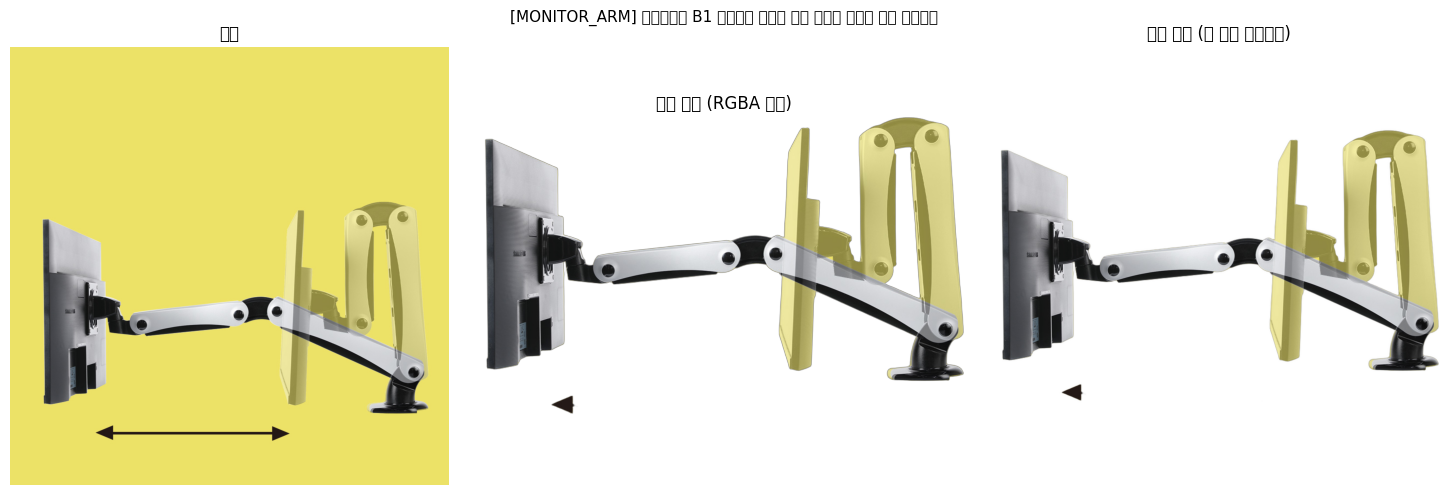

In [35]:
import importlib, config as _config_mod
importlib.reload(_config_mod)
from config import SKIP_REMBG_CATEGORIES

# 이미지 다운로드
resp = requests.get(img_url, timeout=10, verify=certifi.where())
resp.raise_for_status()
original_rgba = Image.open(BytesIO(resp.content)).convert("RGBA")
original_rgb  = original_rgba.convert("RGB")

skip_rembg = cat in SKIP_REMBG_CATEGORIES
if skip_rembg:
    print(f"ℹ️  {cat} 카테고리: 배경 제거 생략 → 정사각형 패딩만 적용")
    w, h = original_rgb.size
    side = max(w, h)
    result_rgb = Image.new("RGB", (side, side), (255, 255, 255))
    result_rgb.paste(original_rgb, ((side - w) // 2, (side - h) // 2))
    cropped_rgba = None
else:
    # vectorizer.py와 동일한 배경 제거 로직
    img_no_bg = rembg_remove(original_rgba, session=rembg_session)
    alpha = img_no_bg.split()[3]
    bbox = alpha.getbbox()

    if bbox is None:
        print("⚠️  배경 제거 결과가 완전 투명 → 원본 정사각형 패딩 사용")
        w, h = original_rgb.size
        side = max(w, h)
        result_rgb = Image.new("RGB", (side, side), (255, 255, 255))
        result_rgb.paste(original_rgb, ((side - w) // 2, (side - h) // 2))
        cropped_rgba = None
    else:
        img_no_bg = img_no_bg.crop(bbox)
        w, h = img_no_bg.size
        side = max(w, h)
        result_rgb = Image.new("RGB", (side, side), (255, 255, 255))
        offset = ((side - w) // 2, (side - h) // 2)
        result_rgb.paste(img_no_bg, offset, mask=img_no_bg.split()[3])
        cropped_rgba = img_no_bg

# 3단 비교: 원본 | RGBA 크롭 또는 상태 | 최종(흰 배경 정사각형)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"[{cat}] {title[:60]}", fontsize=11)

axes[0].imshow(original_rgb)
axes[0].set_title("원본")
axes[0].axis("off")

if cropped_rgba is not None:
    axes[1].imshow(cropped_rgba)
    axes[1].set_title("배경 제거 (RGBA 크롭)")
else:
    label = "생략 (배경제거 스킵)" if skip_rembg else "실패(완전 투명)"
    axes[1].text(0.5, 0.5, label, ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12)
axes[1].axis("off")

axes[2].imshow(result_rgb)
axes[2].set_title("최종 결과 (흰 배경 정사각형)")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 5. 다른 배경색으로 엣지 품질 확인

In [ ]:
if cropped_rgba is None:
    print("배경 제거 실패 — 엣지 확인 불가")
else:
    bg_configs = [
        ((255, 255, 255), "흰 배경"),
        ((0,   0,   0  ), "검정 배경"),
        ((173, 216, 230), "연파랑 배경"),
        ((255, 200, 100), "노란 배경"),
    ]
    fig, axes = plt.subplots(1, len(bg_configs), figsize=(16, 4))
    fig.suptitle("배경색 변경으로 엣지 품질 확인", fontsize=11)

    for ax, (color, label) in zip(axes, bg_configs):
        w, h = cropped_rgba.size
        side = max(w, h)
        bg = Image.new("RGB", (side, side), color)
        offset = ((side - w) // 2, (side - h) // 2)
        bg.paste(cropped_rgba, offset, mask=cropped_rgba.split()[3])
        ax.imshow(bg)
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
